In [2]:
pip install astropy matplotlib numpy scipy pandas scikit-learn photutils specutils ccdproc astroquery jupyterlab

Note: you may need to restart the kernel to use updated packages.


Filename: cc48295.fits
No.    Name      Ver    Type      Cards   Dimensions   Format
  0  PRIMARY       1 PrimaryHDU      26   (50, 1024)   int16   

--- Metadatos principales ---
Objeto: HD145001
Telescopio: 1.88M
Longitud de onda central: 6600

Dimensiones de los datos: (1024, 50)


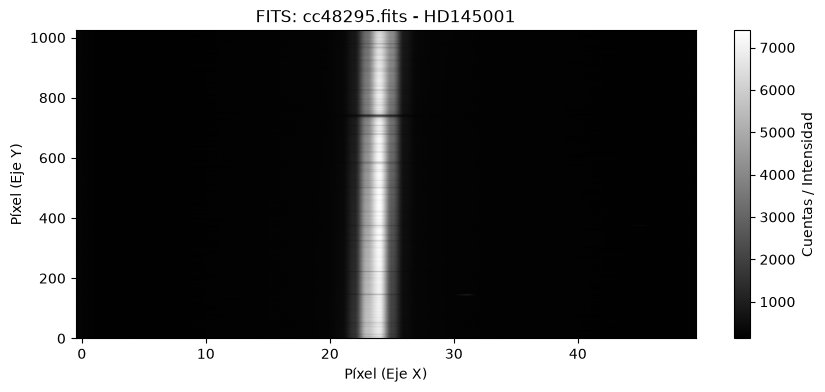

In [2]:
from astropy.io import fits
import matplotlib.pyplot as plt

# 1. Abrir el archivo FITS
filename = 'cc48295.fits'  # Reemplaza por la ruta de tu archivo
with fits.open(filename) as hdul:
    # Muestra un resumen del archivo
    hdul.info()
    
    # 2. Leer la cabecera (metadatos)
    header = hdul[0].header
    print("\n--- Metadatos principales ---")
    print("Objeto:", header.get('OBJECT'))
    print("Telescopio:", header.get('TELESCOP'))
    print("Longitud de onda central:", header.get('CENT-LAM'))
    
    # 3. Extraer la matriz de datos de la imagen/espectro
    data = hdul[0].data
    print("\nDimensiones de los datos:", data.shape)

# 4. (Opcional) Visualizar la imagen o espectro
plt.figure(figsize=(10, 4))
plt.imshow(data, cmap='gray', origin='lower', aspect='auto')
plt.colorbar(label='Cuentas / Intensidad')
plt.title(f"FITS: {filename} - {header.get('OBJECT', 'Sin título')}")
plt.xlabel('Píxel (Eje X)')
plt.ylabel('Píxel (Eje Y)')
plt.show()

Filename: cc48295.fits
No.    Name      Ver    Type      Cards   Dimensions   Format
  0  PRIMARY       1 PrimaryHDU      26   (50, 1024)   int16   

      METADATOS ESPECTROSCÓPICOS
Objeto/Lámpara:  HD145001
Tipo de imagen:  object
Telescopio:      1.88M
Instrumento:     cass-ccd
Red/Grating:     1800/56.35
Central Lambda:  6600 Å
Tiempo Expo:     119 s



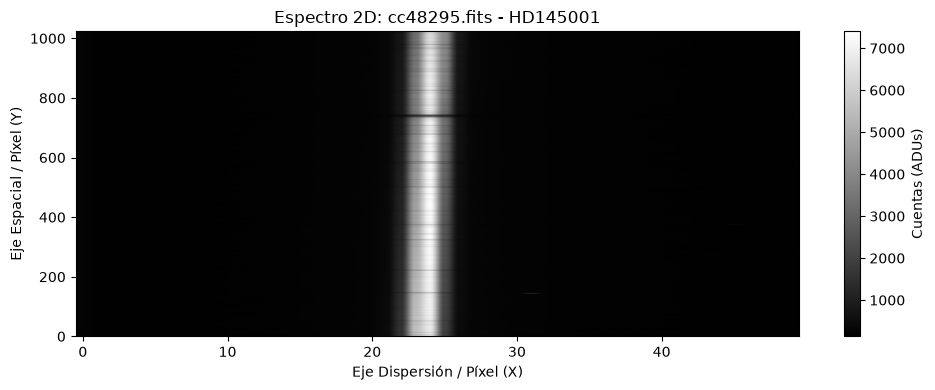

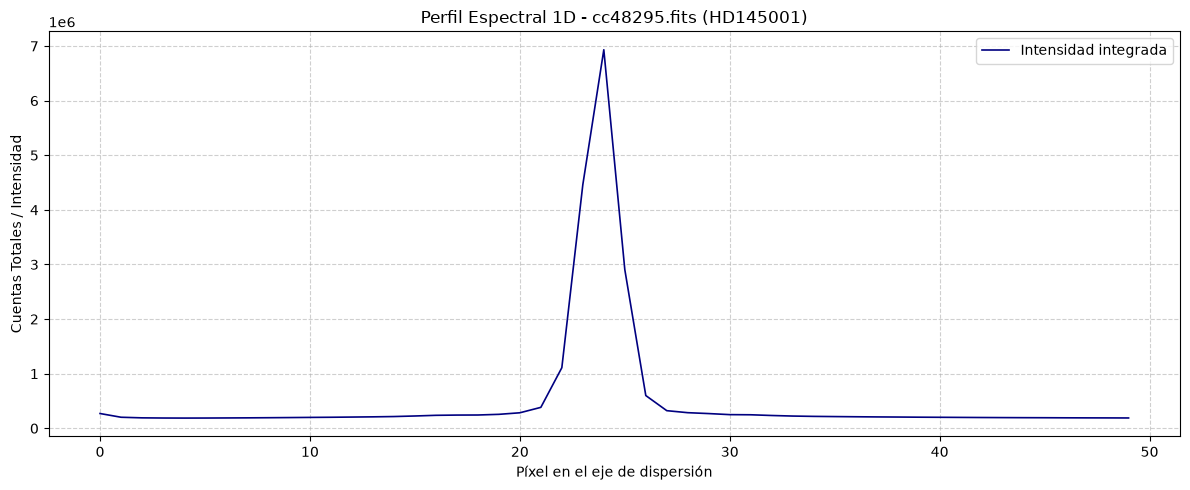

In [3]:
from astropy.io import fits
import numpy as np
import matplotlib.pyplot as plt

def load_fits_data(filename):
    """
    Abre el archivo FITS y retorna la cabecera y la matriz de datos de la imagen 2D.
    """
    with fits.open(filename) as hdul:
        hdul.info()
        header = hdul[0].header.copy()
        data = hdul[0].data.astype(float)
    return header, data


def print_spectroscopic_metadata(header):
    """
    Muestra los metadatos relevantes para la reducción e identificación espectroscópica.
    """
    print("\n" + "=" * 40)
    print("      METADATOS ESPECTROSCÓPICOS")
    print("=" * 40)
    print(f"Objeto/Lámpara:  {header.get('OBJECT', 'N/A')}")
    print(f"Tipo de imagen:  {header.get('IMAGETYP', 'N/A')}")
    print(f"Telescopio:      {header.get('TELESCOP', 'N/A')}")
    print(f"Instrumento:     {header.get('INSTRUME', 'N/A')}")
    print(f"Red/Grating:     {header.get('GRATING', 'N/A')}")
    print(f"Central Lambda:  {header.get('CENT-LAM', 'N/A')} Å")
    print(f"Tiempo Expo:     {header.get('EXPTIME', 'N/A')} s")
    print("=" * 40 + "\n")


def plot_2d_spectrum(data, header, filename=""):
    """
    Visualiza el espectro bidimensional (detector CCD).
    """
    plt.figure(figsize=(10, 4))
    plt.imshow(data, cmap='gray', origin='lower', aspect='auto')
    plt.colorbar(label='Cuentas (ADUs)')
    plt.title(f"Espectro 2D: {filename} - {header.get('OBJECT', 'Sin nombre')}")
    plt.xlabel('Eje Dispersión / Píxel (X)')
    plt.ylabel('Eje Espacial / Píxel (Y)')
    plt.tight_layout()
    plt.show()


def extract_1d_spectrum(data, axis=0):
    """
    Colapsa la rendija/eje espacial para colapsar la señal a un espectro 1D de cuentas por píxel.
    
    Por defecto colapsa a lo largo del eje Y (axis=0), que corresponde
    a la dispersión en el eje X (1024 píxeles).
    """
    # Suma o promedio a lo largo de la rendija
    spectrum_1d = np.sum(data, axis=axis)
    pixels = np.arange(len(spectrum_1d))
    return pixels, spectrum_1d


def plot_1d_spectrum(pixels, intensity, header, filename=""):
    """
    Grafica el perfil espectral 1D (Intensidad vs Píxel).
    """
    plt.figure(figsize=(12, 5))
    plt.plot(pixels, intensity, color='navy', lw=1.2, label='Intensidad integrada')
    plt.title(f"Perfil Espectral 1D - {filename} ({header.get('OBJECT', 'N/A')})")
    plt.xlabel('Píxel en el eje de dispersión')
    plt.ylabel('Cuentas Totales / Intensidad')
    plt.grid(True, linestyle='--', alpha=0.6)
    plt.legend()
    plt.tight_layout()
    plt.show()


# =============================================================================
# EJECUCIÓN PRINCIPAL DEL FLUJO DE TRABAJO
# =============================================================================
if __name__ == "__main__":
    filename = 'cc48295.fits'  # Reemplaza por el nombre de tu archivo FITS
    
    # 1. Cargar datos y metadatos
    header, data_2d = load_fits_data(filename)
    
    # 2. Imprimir información de la cabecera
    print_spectroscopic_metadata(header)
    
    # 3. Visualizar imagen bidimensional de la rendija
    plot_2d_spectrum(data_2d, header, filename)
    
    # 4. Extraer el espectro 1D colapsado
    # Si las líneas espectrales son verticales, se colapsa a lo largo del eje Y (axis=0)
    # Si las líneas espectrales son horizontales, cambiar a axis=1
    pixels, spectrum_1d = extract_1d_spectrum(data_2d, axis=0)
    
    # 5. Visualizar perfil de líneas espectrales en 1D
    plot_1d_spectrum(pixels, spectrum_1d, header, filename)

<>:75: SyntaxWarning: "\l" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\l"? A raw string is also an option.
<>:75: SyntaxWarning: "\l" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\l"? A raw string is also an option.
/tmp/ipykernel_21686/1320675893.py:75: SyntaxWarning: "\l" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\l"? A raw string is also an option.
  ax1.set_xlabel("Longitud de onda $\lambda$ (nm)")


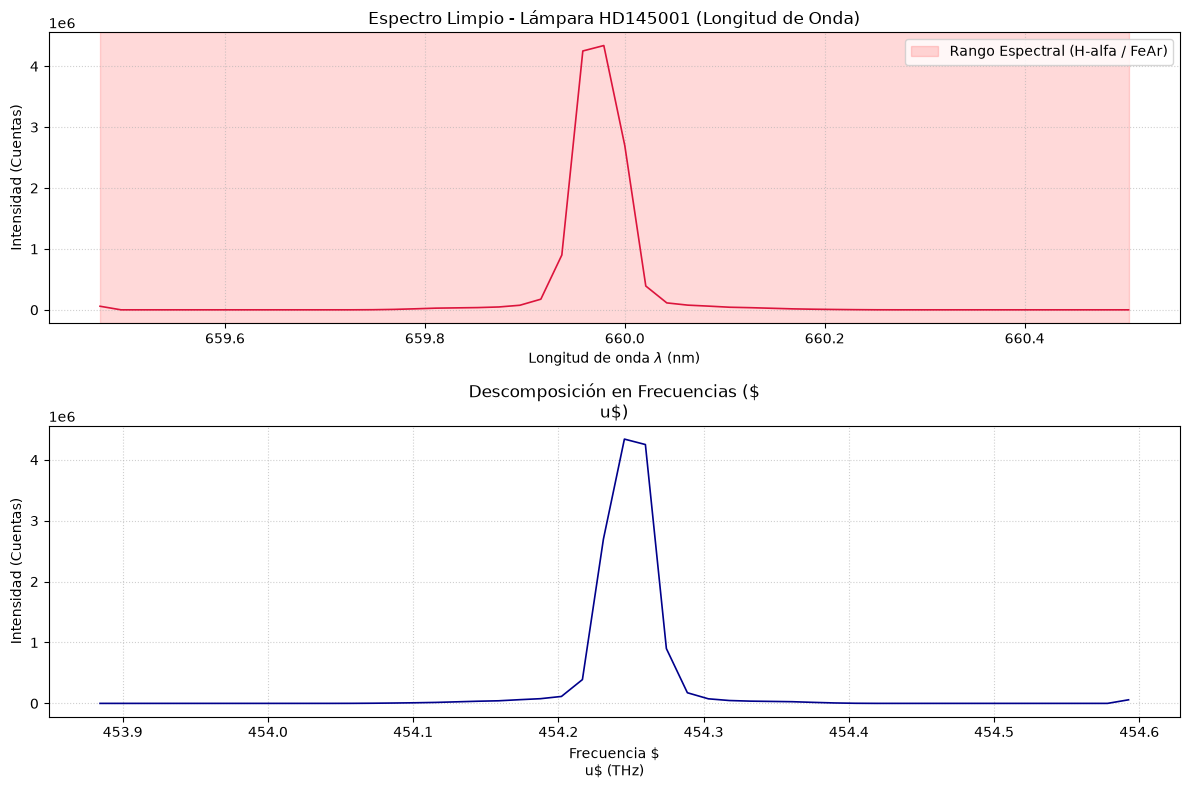

In [4]:
from astropy.io import fits
import numpy as np
import matplotlib.pyplot as plt
from scipy.ndimage import median_filter
from scipy.constants import c  # Velocidad de la luz en m/s

# =============================================================================
# 1. CARGA Y LIMPIEZA DE DATOS (REDUCCIÓN DE RUIDO)
# =============================================================================
def load_and_clean_data(filename):
    """
    Carga el FITS y remueve el fondo (sky/bias) y los rayos cósmicos.
    """
    with fits.open(filename) as hdul:
        header = hdul[0].header.copy()
        data = hdul[0].data.astype(float)
    
    # 1. Sustracción de pedestal/fondo estimado (mediana de las regiones sin señal)
    background = np.median(data)
    data_subtracted = data - background
    data_subtracted[data_subtracted < 0] = 0.0  # Eliminar ruido numérico negativo
    
    # 2. Filtro de mediana (3x3) para suavizar ruido de lectura y picos espurios
    cleaned_data = median_filter(data_subtracted, size=(3, 3))
    
    return header, cleaned_data

# =============================================================================
# 2. EXTRACCIÓN Y CALIBRACIÓN DE LONGITUD DE ONDA Y FRECUENCIA
# =============================================================================
def calibrate_wavelength_and_frequency(header, num_pixels=1024):
    """
    Calcula el eje de longitud de onda (Å/nm) y frecuencia (Hz) basándose en 
    los metadatos de la red de difracción (1800 l/mm) y el centro a 6600 Å.
    """
    central_wavelength = float(header.get('CENT-LAM', 6600))  # En Ángstroms (Å)
    
    # Dispersión aproximada (~0.2 Å/píxel para red de 1800 l/mm en este espectrógrafo)
    dispersion = 0.21  # Å / píxel
    pixel_center = num_pixels / 2.0
    
    # Eje 1D de Longitud de Onda: lambda(px) = lambda_central + (px - px_center) * dispersión
    pixels = np.arange(num_pixels)
    wavelengths_angstrom = central_wavelength + (pixels - pixel_center) * dispersion
    wavelengths_nm = wavelengths_angstrom / 10.0  # Convertir a nanómetros (nm)
    
    # Eje de Frecuencias: nu = c / lambda
    wavelengths_m = wavelengths_angstrom * 1e-10  # Convertir Å a metros
    frequencies_hz = c / wavelengths_m            # Frecuencia en Hz
    
    return wavelengths_angstrom, wavelengths_nm, frequencies_hz

# =============================================================================
# 3. EXTRACCIÓN DEL ESPECTRO 1D
# =============================================================================
def extract_1d_spectrum(cleaned_data):
    """
    Suma el perfil espacial a lo largo de la rendija (eje Y) para obtener el espectro 1D.
    """
    spectrum_1d = np.sum(cleaned_data, axis=0)
    return spectrum_1d

# =============================================================================
# 4. VISUALIZACIÓN POR COLORES / ESPECTRO VISIBLE Y FRECUENCIAS
# =============================================================================
def plot_calibrated_spectrum(wavelengths_nm, frequencies_hz, intensity, header):
    """
    Genera los gráficos del espectro limpio descompuesto en Nanómetros (Colores) y Frecuencias.
    """
    fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 8))
    
    # --- Gráfico 1: Longitud de Onda / Colores (nm) ---
    ax1.plot(wavelengths_nm, intensity, color='crimson', linewidth=1.2)
    ax1.set_title(f"Espectro Limpio - Lámpara {header.get('OBJECT', 'FeAr')} (Longitud de Onda)")
    ax1.set_xlabel("Longitud de onda $\lambda$ (nm)")
    ax1.set_ylabel("Intensidad (Cuentas)")
    ax1.grid(True, linestyle=':', alpha=0.6)
    
    # Sombreado indicativo del color en el espectro visible (~660 nm es Rojo)
    ax1.axvspan(wavelengths_nm.min(), wavelengths_nm.max(), color='red', alpha=0.15, label='Rango Espectral (H-alfa / FeAr)')
    ax1.legend(loc='upper right')

    # --- Gráfico 2: Frecuencias (THz) ---
    frequencies_thz = frequencies_hz / 1e12  # Convertir Hz a TeraHertz (THz)
    ax2.plot(frequencies_thz, intensity, color='darkblue', linewidth=1.2)
    ax2.set_title("Descomposición en Frecuencias ($\nu$)")
    ax2.set_xlabel("Frecuencia $\nu$ (THz)")
    ax2.set_ylabel("Intensidad (Cuentas)")
    ax2.grid(True, linestyle=':', alpha=0.6)
    
    plt.tight_layout()
    plt.show()

# =============================================================================
# EJECUCIÓN DEL FLUJO COMPLETO
# =============================================================================
if __name__ == "__main__":
    filename = 'cc48295.fits'  # Reemplazar con la ruta de tu archivo FITS
    
    # 1. Cargar y filtrar ruido
    header, clean_2d = load_and_clean_data(filename)
    
    # 2. Mapear a escala física (Longitud de onda y Frecuencia)
    wl_angstrom, wl_nm, freqs_hz = calibrate_wavelength_and_frequency(header, num_pixels=clean_2d.shape[1])
    
    # 3. Colapsar a espectro 1D limpio
    spectrum_1d = extract_1d_spectrum(clean_2d)
    
    # 4. Graficar espectro descompuesto
    plot_calibrated_spectrum(wl_nm, freqs_hz, spectrum_1d, header)

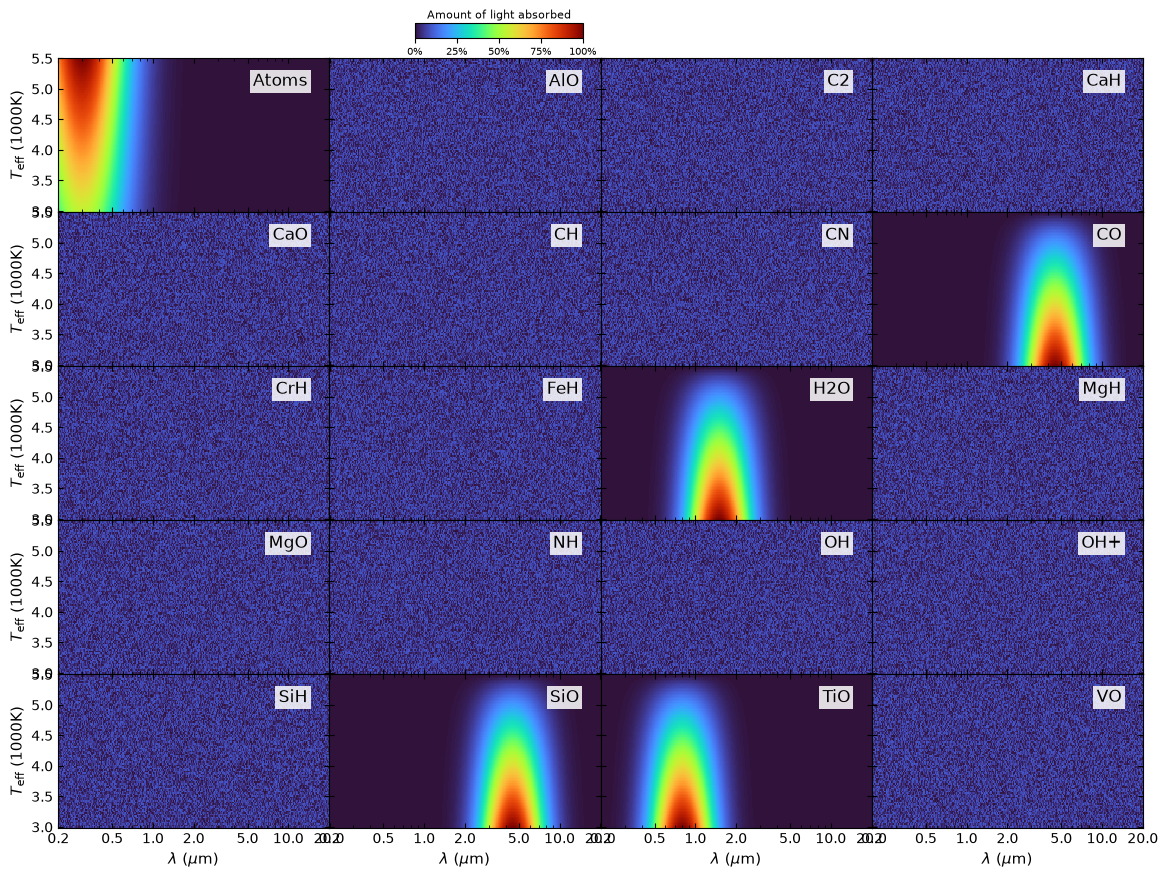

In [5]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors

# 1. Configurar parámetros generales de Matplotlib estilo publicación
plt.rcParams['font.family'] = 'DejaVu Sans'
plt.rcParams['mathtext.fontset'] = 'dejavusans'

# 2. Definir rejilla de datos de prueba / simulación
# Filas x Columnas = 5 x 4
molecules = [
    ["Atoms", "AlO", "C2", "CaH"],
    ["CaO", "CH", "CN", "CO"],
    ["CrH", "FeH", "H2O", "MgH"],
    ["MgO", "NH", "OH", "OH+"],
    ["SiH", "SiO", "TiO", "VO"]
]

# Rango físico de los ejes
wavelengths = np.logspace(np.log10(0.2), np.log10(20.0), 500)  # \lambda (μm) de 0.2 a 20 μm
t_eff = np.linspace(3.0, 5.5, 100)                             # T_eff en (1000 K)

# Crear malla 2D para evaluar o simular datos (p. ej. absorción)
W, T = np.meshgrid(wavelengths, t_eff)

fig, axes = plt.subplots(nrows=5, ncols=4, figsize=(14, 10), sharex=True, sharey=True)
plt.subplots_adjust(wspace=0.0, hspace=0.0)

# Mapa de color customizado o estándar (Turbo/Rainbow invertido)
cmap = plt.get_cmap('turbo')

for i in range(5):
    for j in range(4):
        ax = axes[i, j]
        mol_name = molecules[i][j]
        
        # Generar o cargar matriz de absorción 2D para cada molécula
        # Sustituir 'data_2d' por tus modelos sintéticos / opacidades Exomol/BT-Settl
        if mol_name == "Atoms":
            data_2d = np.exp(-((np.log10(W) - np.log10(0.3))**2) / 0.1) * (T / 5.5)
        elif mol_name in ["TiO", "H2O", "CO", "SiO"]:
            center = 0.8 if mol_name == "TiO" else (1.5 if mol_name == "H2O" else 4.5)
            data_2d = np.exp(-((np.log10(W) - np.log10(center))**2) / 0.05) * (5.5 - T) / 2.5
        else:
            data_2d = np.random.uniform(0, 0.1, size=W.shape)
        
        # Graficar mapa de intensidad/absorción
        im = ax.pcolormesh(wavelengths, t_eff, data_2d, shading='auto', cmap=cmap, vmin=0, vmax=1)
        ax.set_xscale('log')
        
        # Cuadro con el nombre del átomo/molécula
        ax.text(0.92, 0.90, mol_name, transform=ax.transAxes, fontsize=12,
                verticalalignment='top', horizontalalignment='right',
                bbox=dict(boxstyle='square,pad=0.2', facecolor='white', alpha=0.85, edgecolor='none'))
        
        # Marcas y ticks de ejes
        ax.tick_params(axis='both', which='both', direction='in', top=True, right=True)
        
        # Configurar límites y ticks
        if j == 0:
            ax.set_ylabel(r"$T_{\mathrm{eff}}\ (1000\mathrm{K})$", fontsize=11)
            ax.set_yticks([3.0, 3.5, 4.0, 4.5, 5.0, 5.5])
        
        if i == 4:
            ax.set_xlabel(r"$\lambda\ (\mu\mathrm{m})$", fontsize=11)
            ax.set_xticks([0.2, 0.5, 1.0, 2.0, 5.0, 10, 20])
            ax.get_xaxis().set_major_formatter(plt.ScalarFormatter())

# Agregar leyenda de barra de color y metadatos en el cuadro central/superior
cbar_ax = fig.add_axes([0.38, 0.90, 0.12, 0.015]) # [left, bottom, width, height]
cb = fig.colorbar(im, cax=cbar_ax, orientation='horizontal')
cb.set_ticks([0, 0.25, 0.5, 0.75, 1.0])
cb.ax.set_xticklabels(['0%', '25%', '50%', '75%', '100%'], fontsize=7)
cb.ax.set_title("Amount of light absorbed", fontsize=8, pad=3)

plt.show()